# InternVL3 Document-Aware Batch Processing


## 1. Imports

## 0. Pre-emptive Memory Cleanup

**CRITICAL for V100**: Run this cell first to prevent OOM errors when switching between models.

In [1]:
# Pre-emptive V100 Memory Cleanup - Run FIRST to prevent OOM errors
from rich import print as rprint

from common.gpu_optimization import emergency_cleanup

rprint("[bold red]🧹 PRE-EMPTIVE V100 MEMORY CLEANUP[/bold red]")
rprint("[yellow]Clearing any existing model caches before loading...[/yellow]")
rprint("[cyan]💡 This prevents OOM errors when switching between models on V100[/cyan]")

# Emergency cleanup to ensure clean slate
emergency_cleanup(verbose=True)

rprint("[green]✅ Memory cleanup complete - ready for model loading[/green]")
rprint("[dim]📋 Next: Import modules and configure settings[/dim]")

🧹 PRE-EMPTIVE V100 MEMORY CLEANUP

Clearing any existing model caches before loading...

💡 This prevents OOM errors when switching between models on V100

🚨 Running V100 emergency GPU cleanup...
🧹 Starting V100-optimized GPU memory cleanup...
   📊 Initial GPU memory: 0.00GB allocated, 0.00GB reserved
   ✅ Final GPU memory: 0.00GB allocated, 0.00GB reserved
   💾 Memory freed: 0.00GB
✅ V100-optimized memory cleanup complete
✅ V100 emergency cleanup complete


✅ Memory cleanup complete - ready for model loading

📋 Next: Import modules and configure settings

In [2]:
# Core imports
import sys
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from rich import print as rprint
from rich.console import Console

warnings.filterwarnings('ignore')
console = Console()

# Import simplified system components only
from common.batch_analytics import BatchAnalytics
from common.batch_reporting import BatchReporter
from common.batch_visualizations import BatchVisualizer
from common.evaluation_metrics import load_ground_truth
from common.extraction_parser import discover_images
from common.field_definitions_loader import SimpleFieldLoader

rprint("[green]✅ Simplified imports completed successfully[/green]")
rprint("[cyan]🔧 Using simplified system - no legacy complexity[/cyan]")

✅ Simplified imports completed successfully

🔧 Using simplified system - no legacy complexity

## 2. Configuration

In [3]:
# Environment-specific base paths
ENVIRONMENT_BASES = {
    'sandbox': '/home/jovyan/nfs_share/tod',
    'efs': '/efs/shared/PoC_data'
}
base_data_path = ENVIRONMENT_BASES['sandbox']
CONFIG = {
    # Model settings
    # 'MODEL_PATH': "/efs/shared/PTM/InternVL3-8B",
    'MODEL_PATH': "/home/jovyan/nfs_share/models/InternVL3-8B",

    # Batch settings - Using base path for consistency
    'DATA_DIR': f'{base_data_path}/evaluation_data',
    'GROUND_TRUTH': f'{base_data_path}/evaluation_data/ground_truth.csv',
    'OUTPUT_BASE': f'{base_data_path}/output',
    'MAX_IMAGES': None,  # None for all, or set limit
    'DOCUMENT_TYPES': None,  # None for all, or ['invoice', 'receipt']

    # Verbosity control
    'VERBOSE': True,
    'SHOW_PROMPTS': True,

    # V100 optimization settings
    'USE_QUANTIZATION': False,
    'DEVICE_MAP': 'auto',
    'MAX_NEW_TOKENS': 4000,
    'TORCH_DTYPE': 'bfloat16',
    'LOW_CPU_MEM_USAGE': True
}

PROMPT_CONFIG = {
    'detection_file': 'prompts/document_type_detection.yaml',
    'detection_key': 'detection',
    'extraction_files': {
        'INVOICE': 'prompts/internvl3_prompts.yaml',
        'RECEIPT': 'prompts/internvl3_prompts.yaml',
        'BANK_STATEMENT': 'prompts/internvl3_prompts.yaml'
    },
    'extraction_keys': {
        'INVOICE': 'invoice',
        'RECEIPT': 'receipt', 
        'BANK_STATEMENT': 'bank_statement'
    }
}

print("✅ Configuration loaded")
print(f"🎯 Model: {CONFIG['MODEL_PATH']}")
print("📊 Prompt config: InternVL3 simplified prompts (internvl3_prompts.yaml)")
print(f"🔊 Verbose mode: {'ON - Detailed output' if CONFIG['VERBOSE'] else 'OFF - Minimal output'}")
print(f"📝 Show prompts: {'ON' if CONFIG['SHOW_PROMPTS'] else 'OFF'} (requires VERBOSE=True)")

✅ Configuration loaded
🎯 Model: /home/jovyan/nfs_share/models/InternVL3-8B
📊 Prompt config: InternVL3 simplified prompts (internvl3_prompts.yaml)
🔊 Verbose mode: ON - Detailed output
📝 Show prompts: ON (requires VERBOSE=True)


## 3. Output Directory Setup

In [4]:
# Setup output directories - Handle both absolute and relative paths
from pathlib import Path

# Convert OUTPUT_BASE to Path and handle absolute/relative paths
OUTPUT_BASE = Path(CONFIG['OUTPUT_BASE'])
if not OUTPUT_BASE.is_absolute():
    # If relative, make it relative to current working directory
    OUTPUT_BASE = Path.cwd() / OUTPUT_BASE

BATCH_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

OUTPUT_DIRS = {
    'base': OUTPUT_BASE,
    'batch': OUTPUT_BASE / 'batch_results',
    'csv': OUTPUT_BASE / 'csv',
    'visualizations': OUTPUT_BASE / 'visualizations',
    'reports': OUTPUT_BASE / 'reports'
}

for dir_path in OUTPUT_DIRS.values():
    dir_path.mkdir(parents=True, exist_ok=True)

print("✅ Output directories created")
print(f"📁 Base: {OUTPUT_BASE}")
print(f"⏰ Timestamp: {BATCH_TIMESTAMP}")

✅ Output directories created
📁 Base: /home/jovyan/nfs_share/tod/output
⏰ Timestamp: 20250918_003042


## 4. Initialize Schema

In [5]:
# Initialize simplified field loader
field_loader = SimpleFieldLoader()
supported_types = field_loader.get_supported_document_types()
total_fields = len(field_loader.get_document_fields("universal"))

print(f"✅ SimpleFieldLoader initialized with {total_fields} total fields")
print(f"📋 Supported document types: {supported_types}")

# We'll initialize the processor in the batch processing loop
print("✅ Field definitions ready for document-aware processing")
print("🎯 Processor will be initialized during batch processing (lazy loading)")
print("🔧 Simplified system - no complex template rendering needed")

✅ SimpleFieldLoader initialized with 19 total fields
📋 Supported document types: ['invoice', 'receipt', 'bank_statement']
✅ Field definitions ready for document-aware processing
🎯 Processor will be initialized during batch processing (lazy loading)
🔧 Simplified system - no complex template rendering needed


# 5.Load InternVL3 model

In [6]:
# Load InternVL3 model early with intelligent multi-GPU optimization
from common.internvl3_model_loader import load_internvl3_model

rprint("[bold blue]🚀 Loading InternVL3 model with intelligent multi-GPU optimization...[/bold blue]")
rprint("[cyan]Features: Smart quantization, memory management, multi-V100 support[/cyan]")

# Load model using intelligent quantization (auto-detects if 4x V100 memory is sufficient)
internvl3_model, internvl3_tokenizer = load_internvl3_model(
    model_path=CONFIG['MODEL_PATH'],
    use_quantization=CONFIG['USE_QUANTIZATION'],  # Will be overridden based on available memory
    device_map=CONFIG['DEVICE_MAP'],
    max_new_tokens=CONFIG['MAX_NEW_TOKENS'],
    torch_dtype=CONFIG['TORCH_DTYPE'],
    low_cpu_mem_usage=CONFIG['LOW_CPU_MEM_USAGE'],
    verbose=CONFIG['VERBOSE']
)

rprint("[bold green]✅ InternVL3 model ready for enhanced batch processing[/bold green]")
rprint("[cyan]🔧 Multi-GPU optimizations: Intelligent quantization, memory distribution[/cyan]")

# Store for use in processor initialization
MODEL_COMPONENTS = {
    'model': internvl3_model,
    'tokenizer': internvl3_tokenizer,
    'early_loaded': True,
    'optimization_features': ['intelligent_quantization', 'multi_gpu_memory', 'v100_optimized']
}

rprint("[bold blue]🚀 Model components ready for simplified batch processing[/bold blue]")
rprint("[green]✅ Using simplified system - unified BatchDocumentProcessor with DocumentAwareInternVL3Handler[/green]")

🚀 Loading InternVL3 model with intelligent multi-GPU optimization...

Features: Smart quantization, memory management, multi-V100 support

🚀 Loading InternVL3 model with official optimizations...

🔧 Configuring CUDA memory for InternVL3...

📊 Initial CUDA state (Multi-GPU Total): Allocated=0.00GB, Reserved=0.00GB

...

🔧 InternVL3 optimizations active: 16-bit precision, memory management, no vision skipping

✅ InternVL3 model ready for enhanced batch processing

🔧 Multi-GPU optimizations: Intelligent quantization, memory distribution

🚀 Model components ready for simplified batch processing

✅ Using simplified system - unified BatchDocumentProcessor with DocumentAwareInternVL3Handler

## 6. Enhanced Batch Processing

In [7]:
# Discover and filter images - Handle both absolute and relative paths
from pathlib import Path

# Convert DATA_DIR to Path and handle absolute/relative paths
data_dir = Path(CONFIG['DATA_DIR'])
if not data_dir.is_absolute():
    # If relative, make it relative to current working directory
    data_dir = Path.cwd() / data_dir

# Convert GROUND_TRUTH to Path and handle absolute/relative paths
ground_truth_path = Path(CONFIG['GROUND_TRUTH'])
if not ground_truth_path.is_absolute():
    # If relative, make it relative to current working directory
    ground_truth_path = Path.cwd() / ground_truth_path

# Discover images from the resolved data directory
all_images = discover_images(str(data_dir))

# Load ground truth from the resolved path
ground_truth = load_ground_truth(str(ground_truth_path), verbose=CONFIG['VERBOSE'])

# Apply filters
if CONFIG['DOCUMENT_TYPES']:
    filtered = []
    for img in all_images:
        img_name = Path(img).name
        if img_name in ground_truth:
            doc_type = ground_truth[img_name].get('DOCUMENT_TYPE', '').lower()
            if any(dt.lower() in doc_type for dt in CONFIG['DOCUMENT_TYPES']):
                filtered.append(img)
    all_images = filtered

if CONFIG['MAX_IMAGES']:
    all_images = all_images[:CONFIG['MAX_IMAGES']]

rprint(f"[bold green]Ready to process {len(all_images)} images[/bold green]")
rprint(f"[cyan]Data directory: {data_dir}[/cyan]")
rprint(f"[cyan]Ground truth: {ground_truth_path}[/cyan]")
for i, img in enumerate(all_images[:5], 1):
    print(f"  {i}. {Path(img).name}")
if len(all_images) > 5:
    print(f"  ... and {len(all_images) - 5} more")

📊 Ground truth CSV loaded with 9 rows and 20 columns
📋 Available columns: ['image_file', 'DOCUMENT_TYPE', 'BUSINESS_ABN', 'BUSINESS_ADDRESS', 'GST_AMOUNT', 'INVOICE_DATE', 'IS_GST_INCLUDED', 'LINE_ITEM_DESCRIPTIONS', 'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES', 'PAYER_ADDRESS', 'PAYER_NAME', 'STATEMENT_DATE_RANGE', 'SUPPLIER_NAME', 'TOTAL_AMOUNT', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_RECEIVED', 'ACCOUNT_BALANCE']
✅ Using 'image_file' as image identifier column
✅ Ground truth mapping created for 9 images


Ready to process 9 images

Data directory: /home/jovyan/nfs_share/tod/evaluation_data

Ground truth: /home/jovyan/nfs_share/tod/evaluation_data/ground_truth.csv

  1. image_001.png
  2. image_002.png
  3. image_003.png
  4. image_004.png
  5. image_005.png
  ... and 4 more


# 7. Enhanced Modular Batch Processing 🚀



In [8]:
# Use unified BatchDocumentProcessor with simplified InternVL3 handler
from common.batch_processor import BatchDocumentProcessor
from internvl3_document_aware_handler import DocumentAwareInternVL3Handler

# Create simplified InternVL3 handler for BatchDocumentProcessor
rprint("[blue]🔧 Creating simplified InternVL3 document-aware handler[/blue]")
internvl3_handler = DocumentAwareInternVL3Handler(
    model=internvl3_model,
    tokenizer=internvl3_tokenizer,
    config={**CONFIG, 'PROMPT_CONFIG': PROMPT_CONFIG}  # Merge CONFIG and PROMPT_CONFIG
)

# Initialize unified batch processor with InternVL3 handler
batch_processor = BatchDocumentProcessor(
    model=internvl3_handler,  # Use the handler (has required methods)
    processor=None,  # InternVL3 doesn't need separate processor
    prompt_config=PROMPT_CONFIG,
    ground_truth_csv=str(ground_truth_path)
)

# Process batch using the correct method signature
rprint("[bold blue]🚀 Starting enhanced batch processing with unified processor[/bold blue]")
rprint("[cyan]Features: Document-aware evaluation, field filtering, enhanced accuracy[/cyan]")

# Use the correct process_batch method
batch_results, processing_times, document_types_found = batch_processor.process_batch(
    image_paths=all_images,
    verbose=CONFIG['VERBOSE']
)

rprint(f"[bold green]✅ Batch processing complete: {len(batch_results)} results[/bold green]")
rprint(f"[cyan]Document types found: {document_types_found}[/cyan]")
rprint(f"[cyan]Average processing time: {sum(processing_times)/len(processing_times):.2f}s[/cyan]")

🔧 Creating simplified InternVL3 document-aware handler

✅ DocumentAwareInternVL3Handler initialized with simplified architecture

🚀 Starting enhanced batch processing with unified processor

Features: Document-aware evaluation, field filtering, enhanced accuracy

📊 Ground truth CSV loaded with 9 rows and 20 columns
📋 Available columns: ['image_file', 'DOCUMENT_TYPE', 'BUSINESS_ABN', 'BUSINESS_ADDRESS', 'GST_AMOUNT', 'INVOICE_DATE', 'IS_GST_INCLUDED', 'LINE_ITEM_DESCRIPTIONS', 'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES', 'PAYER_ADDRESS', 'PAYER_NAME', 'STATEMENT_DATE_RANGE', 'SUPPLIER_NAME', 'TOTAL_AMOUNT', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_RECEIVED', 'ACCOUNT_BALANCE']
✅ Using 'image_file' as image identifier column
✅ Ground truth mapping created for 9 images


...

[9/9] image_009.png: bank_statement - Accuracy: 0.0% - Time: 5.33s

──────────────────────────────────────────── Batch Processing Complete ────────────────────────────────────────────

✅ Batch processing complete: 9 results

Document types found: {'receipt': 3, 'bank_statement': 3, 'invoice': 3}

Average processing time: 11.12s

# 8.Create analytics

In [9]:
# Create analytics using standard BatchAnalytics
analytics = BatchAnalytics(batch_results, processing_times)

# Generate and save DataFrames
saved_files, df_results, df_summary, df_doctype_stats, df_field_stats = analytics.save_all_dataframes(
    OUTPUT_DIRS['csv'], BATCH_TIMESTAMP, verbose=CONFIG['VERBOSE']
)

# Display key results
rprint("\n[bold blue]📊 Results Summary[/bold blue]")
display(df_summary)

if not df_doctype_stats.empty:
    rprint("\n[bold blue]📋 Document Type Performance[/bold blue]")
    display(df_doctype_stats)

✅ DataFrames saved to /home/jovyan/nfs_share/tod/output/csv

📊 Results Summary

,Value
Total Images,9.000000
Successful Extractions,9.000000
Failed Extractions,0.000000
Average Accuracy (%),49.206349
Median Accuracy (%),57.142857
Min Accuracy (%),0.000000
Max Accuracy (%),85.714286
Average Processing Time (s),11.117547
Total Processing Time (s),100.057926
Throughput (images/min),5.396874


📋 Document Type Performance

,overall_accuracy_mean,overall_accuracy_median,overall_accuracy_std,overall_accuracy_min,overall_accuracy_max,processing_time_mean,processing_time_median,count
document_type,,,,,,,,
bank_statement,14.29,14.29,14.29,0.00,28.57,19.96,9.85,3
invoice,61.90,64.29,4.12,57.14,64.29,7.17,7.28,3
receipt,71.43,71.43,14.29,57.14,85.71,6.22,6.54,3


## 8. Export Model-Specific CSV

In [10]:
# Create model-specific CSV file for model comparison
FIELD_COLUMNS = [
    'DOCUMENT_TYPE', 'BUSINESS_ABN', 'SUPPLIER_NAME', 'BUSINESS_ADDRESS', 
    'PAYER_NAME', 'PAYER_ADDRESS', 'INVOICE_DATE', 'LINE_ITEM_DESCRIPTIONS',
    'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES',
    'IS_GST_INCLUDED', 'GST_AMOUNT', 'TOTAL_AMOUNT', 'STATEMENT_DATE_RANGE',
    'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_AMOUNTS_RECEIVED',
    'ACCOUNT_BALANCE'
]

# Detect model variant from path
model_variant = "8B" if "8B" in CONFIG['MODEL_PATH'] else "2B"
model_suffix = f"internvl3_{model_variant.lower()}"

# Create comprehensive results data matching Llama structure
internvl3_csv_data = []

for i, result in enumerate(batch_results):
    image_name = result['image_name']
    doc_type = result.get('document_type', '').lower()
    processing_time = result.get('processing_time', 0)
    
    # Extract fields from result
    extraction_result = result.get('extraction_result', {})
    extracted_fields = extraction_result.get('extracted_data', {})
    evaluation = result.get('evaluation', {})
    
    # Calculate metrics - Enhanced accuracy calculation
    overall_accuracy = evaluation.get('overall_accuracy', 0) * 100 if evaluation else 0
    fields_extracted = evaluation.get('fields_extracted', 0) if evaluation else 0
    fields_matched = evaluation.get('fields_matched', 0) if evaluation else 0
    total_fields = evaluation.get('total_fields', len(FIELD_COLUMNS)) if evaluation else len(FIELD_COLUMNS)
    
    # Create row data with enhanced structure matching Llama
    row_data = {
        'image_file': image_name,
        'image_name': image_name,
        'document_type': doc_type,
        'processing_time': processing_time,
        'field_count': total_fields,
        'found_fields': fields_extracted,
        'field_coverage': (fields_extracted / total_fields * 100) if total_fields > 0 else 0,
        'prompt_used': f"{model_suffix}_{doc_type}",
        'timestamp': datetime.now().isoformat(),
        'overall_accuracy': overall_accuracy,
        'fields_extracted': fields_extracted,
        'fields_matched': fields_matched,
        'total_fields': total_fields
    }
    
    # Add all field values
    for field in FIELD_COLUMNS:
        row_data[field] = extracted_fields.get(field, 'NOT_FOUND')
    
    internvl3_csv_data.append(row_data)

# Create DataFrame and save with enhanced validation
internvl3_df = pd.DataFrame(internvl3_csv_data)
internvl3_csv_path = OUTPUT_DIRS['csv'] / f"{model_suffix}_batch_results_{BATCH_TIMESTAMP}.csv"
internvl3_df.to_csv(internvl3_csv_path, index=False)

rprint("\n[bold green]✅ InternVL3 model-specific CSV exported:[/bold green]")
rprint(f"[cyan]📄 File: {internvl3_csv_path}[/cyan]")
rprint(f"[cyan]📊 Structure: {len(internvl3_df)} rows × {len(internvl3_df.columns)} columns[/cyan]")
rprint("[cyan]🔗 Compatible with model_comparison.ipynb pattern: *internvl3*batch*results*.csv[/cyan]")

# Enhanced sample display matching Llama structure
rprint("\n[bold blue]📋 Sample exported data (first 3 rows, key columns):[/bold blue]")
sample_cols = ['image_file', 'document_type', 'overall_accuracy', 'processing_time', 'found_fields', 'field_coverage']
if len(internvl3_df) > 0:
    display(internvl3_df[sample_cols].head(3))
else:
    rprint("[yellow]⚠️ No data to display[/yellow]")

# Verification: Show accuracy values to confirm they're correct
if len(internvl3_df) > 0:
    accuracy_values = internvl3_df['overall_accuracy'].tolist()
    rprint("\n[bold blue]🔍 Accuracy verification:[/bold blue]")
    rprint(f"[cyan]Raw accuracy values: {[f'{acc:.1f}%' for acc in accuracy_values]}[/cyan]")
    rprint(f"[cyan]Average: {np.mean(accuracy_values):.2f}% | Range: {min(accuracy_values):.1f}% - {max(accuracy_values):.1f}%[/cyan]")
    
    # Field coverage verification
    coverage_values = internvl3_df['field_coverage'].tolist()
    rprint(f"[cyan]Field coverage: {[f'{cov:.1f}%' for cov in coverage_values]}[/cyan]")
    rprint(f"[cyan]Average coverage: {np.mean(coverage_values):.1f}%[/cyan]")
    
    # Data completeness check
    non_empty_rows = len([r for r in internvl3_csv_data if r['found_fields'] > 0])
    rprint(f"[cyan]Data completeness: {non_empty_rows}/{len(internvl3_csv_data)} images have extracted fields[/cyan]")

✅ InternVL3 model-specific CSV exported:

📄 File: /home/jovyan/nfs_share/tod/output/csv/internvl3_8b_batch_results_20250918_003042.csv

📊 Structure: 9 rows × 32 columns

🔗 Compatible with model_comparison.ipynb pattern: *internvl3*batch*results*.csv

📋 Sample exported data (first 3 rows, key columns):

...

Raw accuracy values: ['71.4%', '57.1%', '28.6%', '85.7%', '64.3%', '57.1%', '64.3%', '14.3%', '0.0%']

Average: 49.21% | Range: 0.0% - 85.7%

Field coverage: ['0.0%', '0.0%', '0.0%', '0.0%', '0.0%', '0.0%', '0.0%', '0.0%', '0.0%']

Average coverage: 0.0%

Data completeness: 0/9 images have extracted fields

## 9. Create Visualizations

In [11]:
# Create visualizations using standard BatchVisualizer
visualizer = BatchVisualizer()

viz_files = visualizer.create_all_visualizations(
    df_results, 
    df_doctype_stats,
    OUTPUT_DIRS['visualizations'],
    BATCH_TIMESTAMP,
    show=False  # Don't display inline to keep output clean
)

if viz_files:
    rprint(f"[bold green]✅ Created {len(viz_files)} visualizations[/bold green]")

✅ Dashboard saved to /home/jovyan/nfs_share/tod/output/visualizations/dashboard_20250918_003042.png

⚠️ No field-level accuracy data available

✅ Created 1 visualizations

## 10. Generate Reports

In [12]:
# Generate reports using standard BatchReporter
reporter = BatchReporter(
    batch_results, 
    processing_times,
    document_types_found,
    BATCH_TIMESTAMP
)

# Save all reports
report_files = reporter.save_all_reports(
    OUTPUT_DIRS,
    df_results,
    df_summary,
    df_doctype_stats,
    CONFIG['MODEL_PATH'],
    {
        'data_dir': CONFIG['DATA_DIR'],
        'ground_truth': CONFIG['GROUND_TRUTH'],
        'max_images': CONFIG['MAX_IMAGES'],
        'document_types': CONFIG['DOCUMENT_TYPES']
    },
    {
        'use_quantization': CONFIG['USE_QUANTIZATION'],
        'device_map': CONFIG['DEVICE_MAP'],
        'max_new_tokens': CONFIG['MAX_NEW_TOKENS'],
        'torch_dtype': CONFIG['TORCH_DTYPE'],
        'low_cpu_mem_usage': CONFIG['LOW_CPU_MEM_USAGE']
    },
    verbose=CONFIG['VERBOSE']
)

if report_files:
    rprint(f"[bold green]✅ Generated {len(report_files)} reports[/bold green]")

✅ Executive summary saved to /home/jovyan/nfs_share/tod/output/reports/batch_report_20250918_003042.md

✅ Complete results exported to /home/jovyan/nfs_share/tod/output/batch_results/batch_results_20250918_003042.json

✅ Generated 2 reports

## 11. Final Summary

──────────────────────────────────────────── Batch Processing Complete ────────────────────────────────────────────

✅ Processed: 9 images

Success Rate: 100.0%

Average Accuracy: 49.21%

Average Time: 11.12s

Output: /home/jovyan/nfs_share/tod/output

📊 Visual Dashboard:

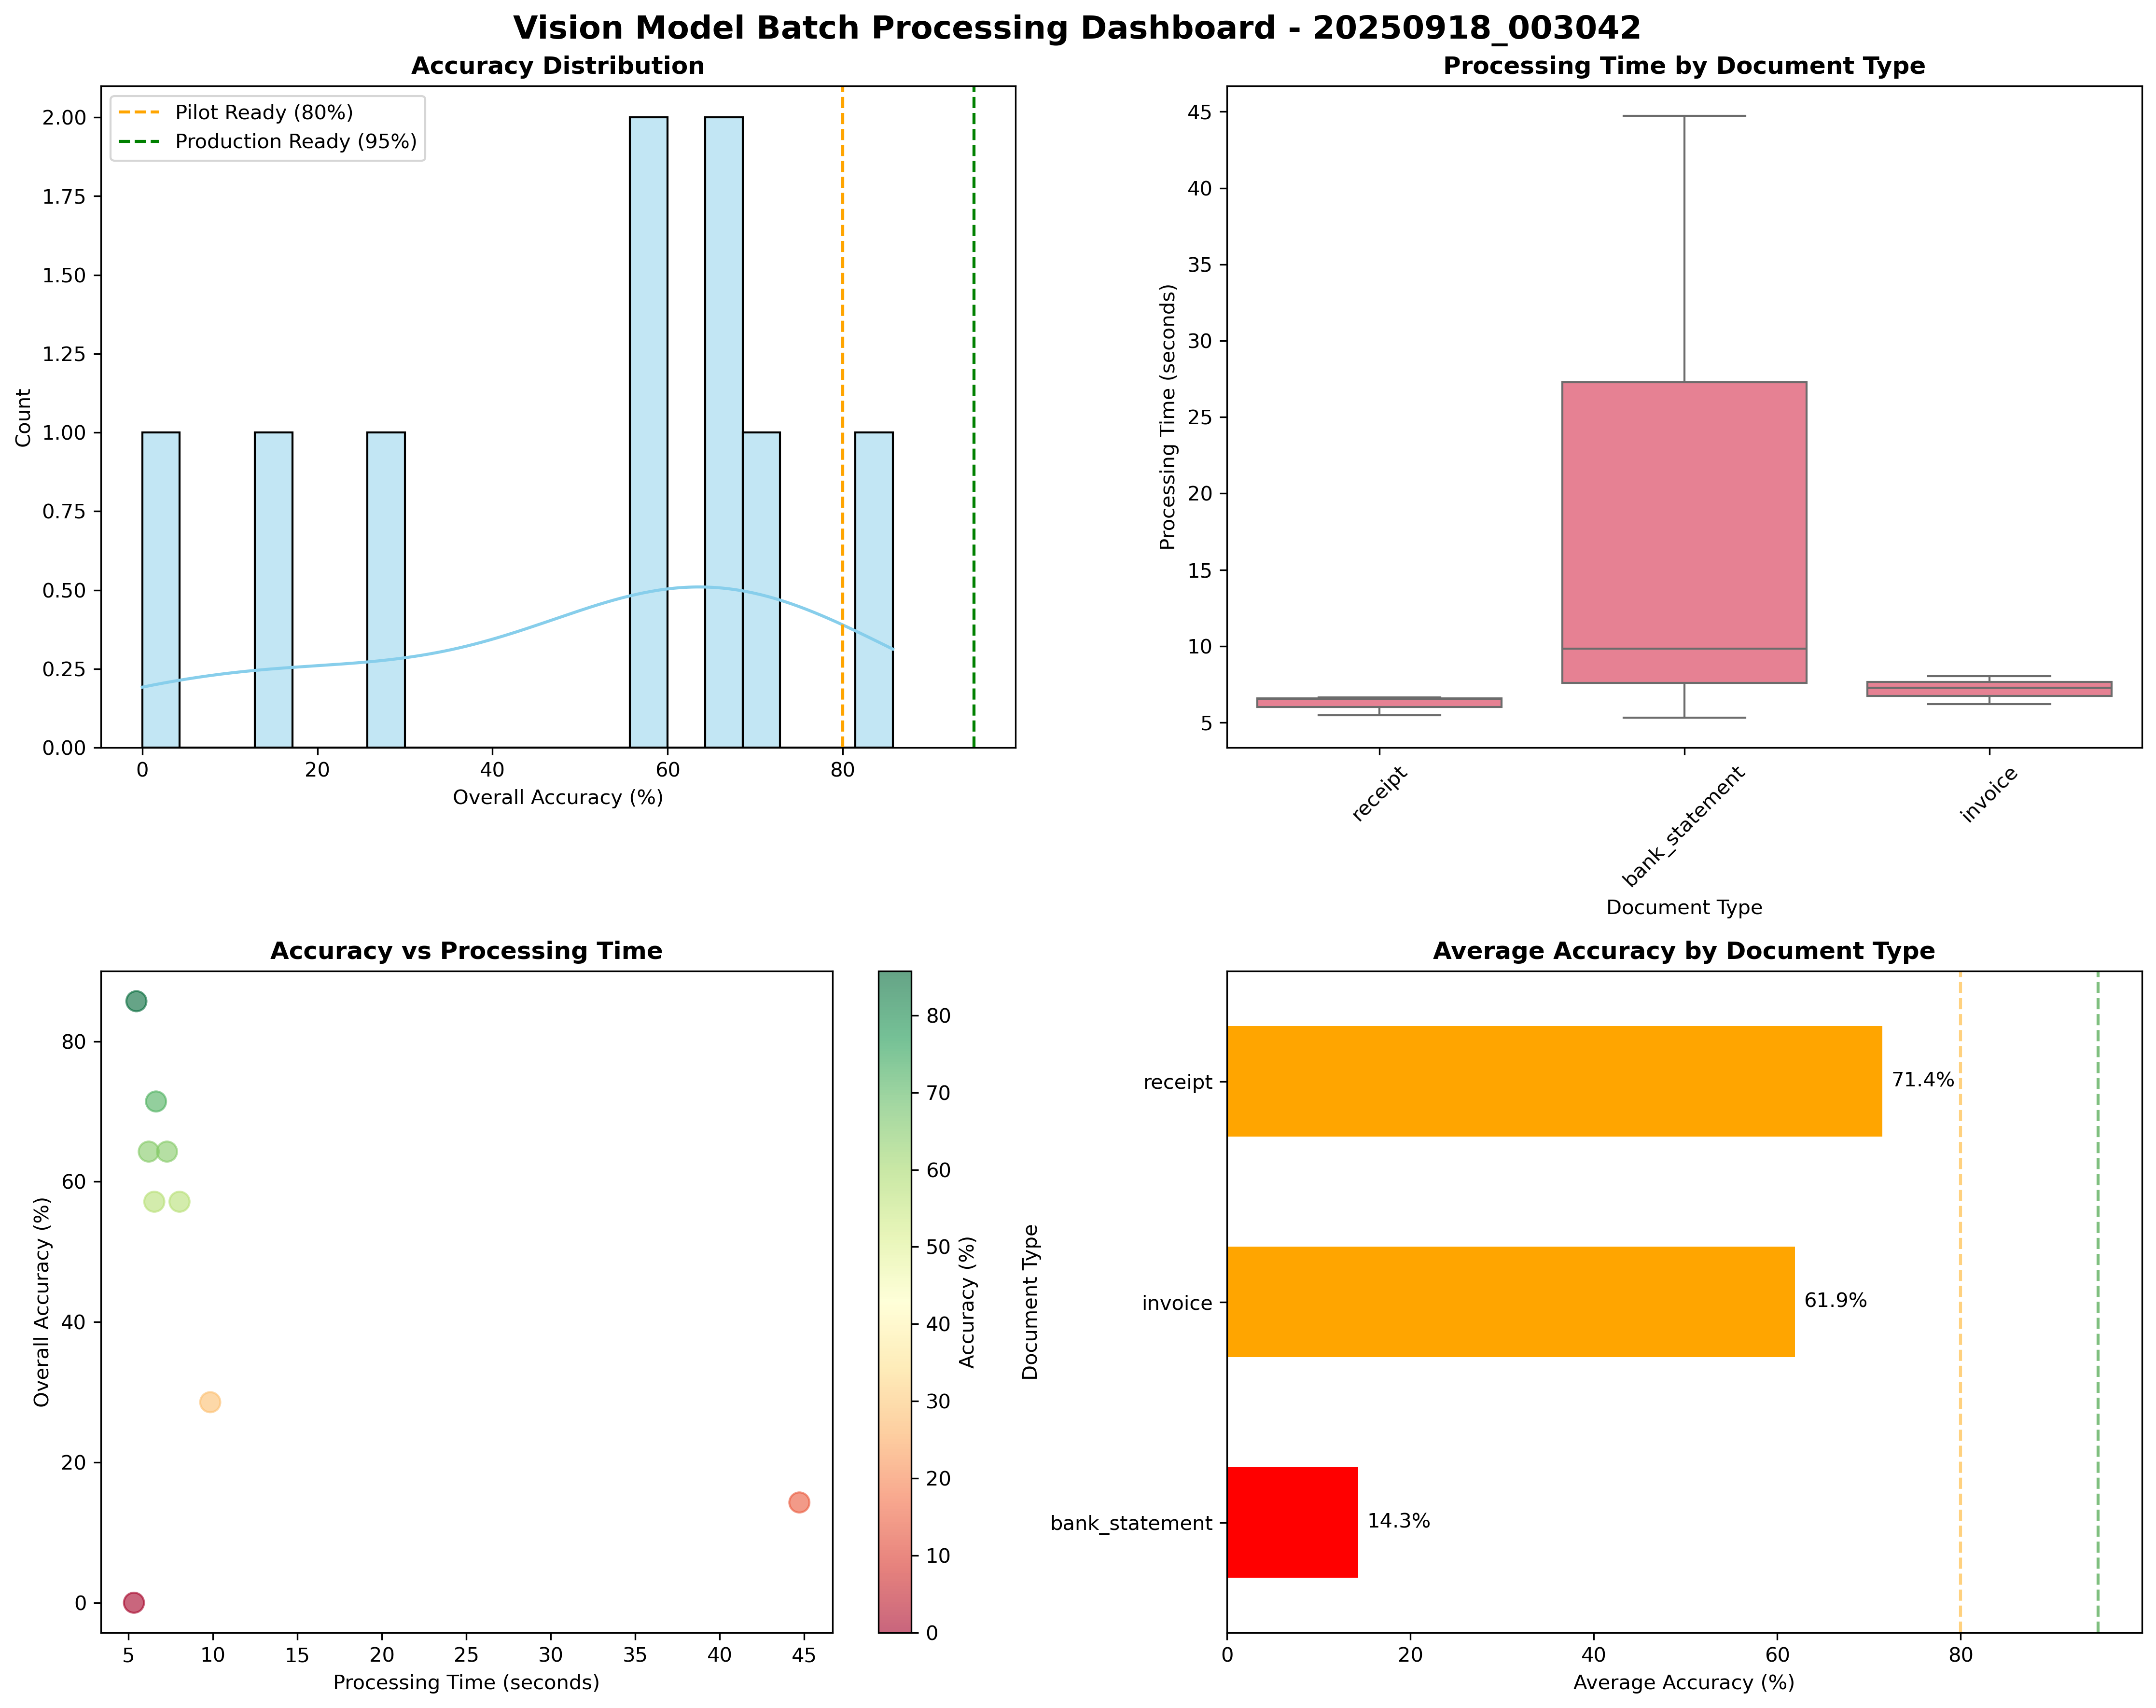

🎉 Clean InternVL3 batch processing complete!

In [13]:
# Display final summary
console.rule("[bold green]Batch Processing Complete[/bold green]")

total_images = len(batch_results)
successful = len([r for r in batch_results if 'error' not in r])
avg_accuracy = df_results['overall_accuracy'].mean() if len(df_results) > 0 else 0

rprint(f"[bold green]✅ Processed: {total_images} images[/bold green]")
rprint(f"[cyan]Success Rate: {(successful/total_images*100):.1f}%[/cyan]")
rprint(f"[cyan]Average Accuracy: {avg_accuracy:.2f}%[/cyan]")
if processing_times:
    rprint(f"[cyan]Average Time: {np.mean(processing_times):.2f}s[/cyan]")
rprint(f"[cyan]Output: {OUTPUT_BASE}[/cyan]")

# Display dashboard if available
dashboard_files = list(OUTPUT_DIRS['visualizations'].glob(f"dashboard_{BATCH_TIMESTAMP}.png"))
if dashboard_files:
    from IPython.display import Image, display
    dashboard_path = dashboard_files[0]
    rprint("\n[bold blue]📊 Visual Dashboard:[/bold blue]")
    display(Image(str(dashboard_path)))

rprint("\n[bold green]🎉 Clean InternVL3 batch processing complete![/bold green]")